In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
# 1. Load and Clean Data
df = pd.read_csv("C:/Users/sudeep/Downloads/Chocolate Sales (2).csv")
df = df.drop_duplicates()

In [4]:
# 2. Preprocessing
# Convert 'Amount' from string ($5,320.00) to float if necessary
if df['Amount'].dtype == 'object':
    df['Amount'] = df['Amount'].str.replace('$', '').str.replace(',', '').astype(float)

In [5]:
# Encode categorical columns
le = LabelEncoder()
categorical_cols = ['Sales Person', 'Country', 'Product']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [6]:
# Handle Date (convert to ordinal or extract year/month)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df = df.drop('Date', axis=1)

In [7]:
X = df.drop('Boxes Shipped', axis=1)
y = df['Boxes Shipped']

# 4. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Model Building (Using Regressor instead of Classifier)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Evaluation
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f} boxes")

R2 Score: 0.7395
Mean Absolute Error: 47.17 boxes


In [15]:
# 1. Define your inputs
input_data = pd.DataFrame({
    'Amount': [4500.00],
    'Country': [2],
    'Product': [3],
    'Sales Person': [9],
    'Year': [2022],
    'Month': [1]
})

# --- THE FIX: Reorder columns to match the training data 'X' ---
input_data = input_data[X.columns] 

# 2. Scale the input
input_scaled = scaler.transform(input_data)

# 3. Make the prediction
prediction = model.predict(input_scaled)

print(f"Predicted Boxes Shipped: {prediction[0]:.2f}")

Predicted Boxes Shipped: 192.93


In [14]:
df.head()

,Sales Person,Country,Product,Amount,Boxes Shipped,Year,Month
0,13,4,14,5320.0,180,2022,1
1,23,2,2,7896.0,94,2022,8
2,9,2,17,4501.0,91,2022,7
3,12,0,17,12726.0,342,2022,4
4,13,4,17,13685.0,184,2022,2


In [16]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. Setup the UI Components
style = {'description_width': 'initial'}
layout = widgets.Layout(width='300px')

amount_input = widgets.FloatText(value=5000.0, description='Amount:', style=style, layout=layout)
country_input = widgets.IntSlider(value=2, min=0, max=10, description='Country ID:', style=style)
product_input = widgets.IntSlider(value=3, min=0, max=20, description='Product ID:', style=style)
sales_input = widgets.IntSlider(value=9, min=0, max=30, description='Sales Person ID:', style=style)
year_input = widgets.IntSlider(value=2024, min=2020, max=2026, description='Year:', style=style)
month_input = widgets.IntSlider(value=1, min=1, max=12, description='Month:', style=style)

predict_btn = widgets.Button(description="Predict Boxes Shipped", button_style='primary', layout=widgets.Layout(width='200px', height='40px'))
output_area = widgets.Output()

# 2. Define the Prediction Logic
def perform_prediction(b):
    with output_area:
        clear_output()
        try:
            # Create input row
            data = pd.DataFrame({
                'Sales Person': [sales_input.value],
                'Country': [country_input.value],
                'Product': [product_input.value],
                'Amount': [amount_input.value],
                'Year': [year_input.value],
                'Month': [month_input.value]
            })
            
            # Ensure column order matches training data 'X'
            data = data[X.columns]
            
            # Scale and Predict
            data_scaled = scaler.transform(data)
            prediction = model.predict(data_scaled)
            
            print(f"✅ Predicted Boxes: {prediction[0]:.2f}")
        except Exception as e:
            print(f"❌ Error: {e}")

predict_btn.on_click(perform_prediction)

# 3. Display the Dashboard
print("--- Interactive Sales Forecast Dashboard ---")
display(widgets.VBox([
    amount_input, country_input, product_input, 
    sales_input, year_input, month_input, 
    predict_btn, output_area
]))

--- Interactive Sales Forecast Dashboard ---


C:\Users\sudeep\AppData\Local\Temp\ipykernel_18360\1964329418.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='viridis')


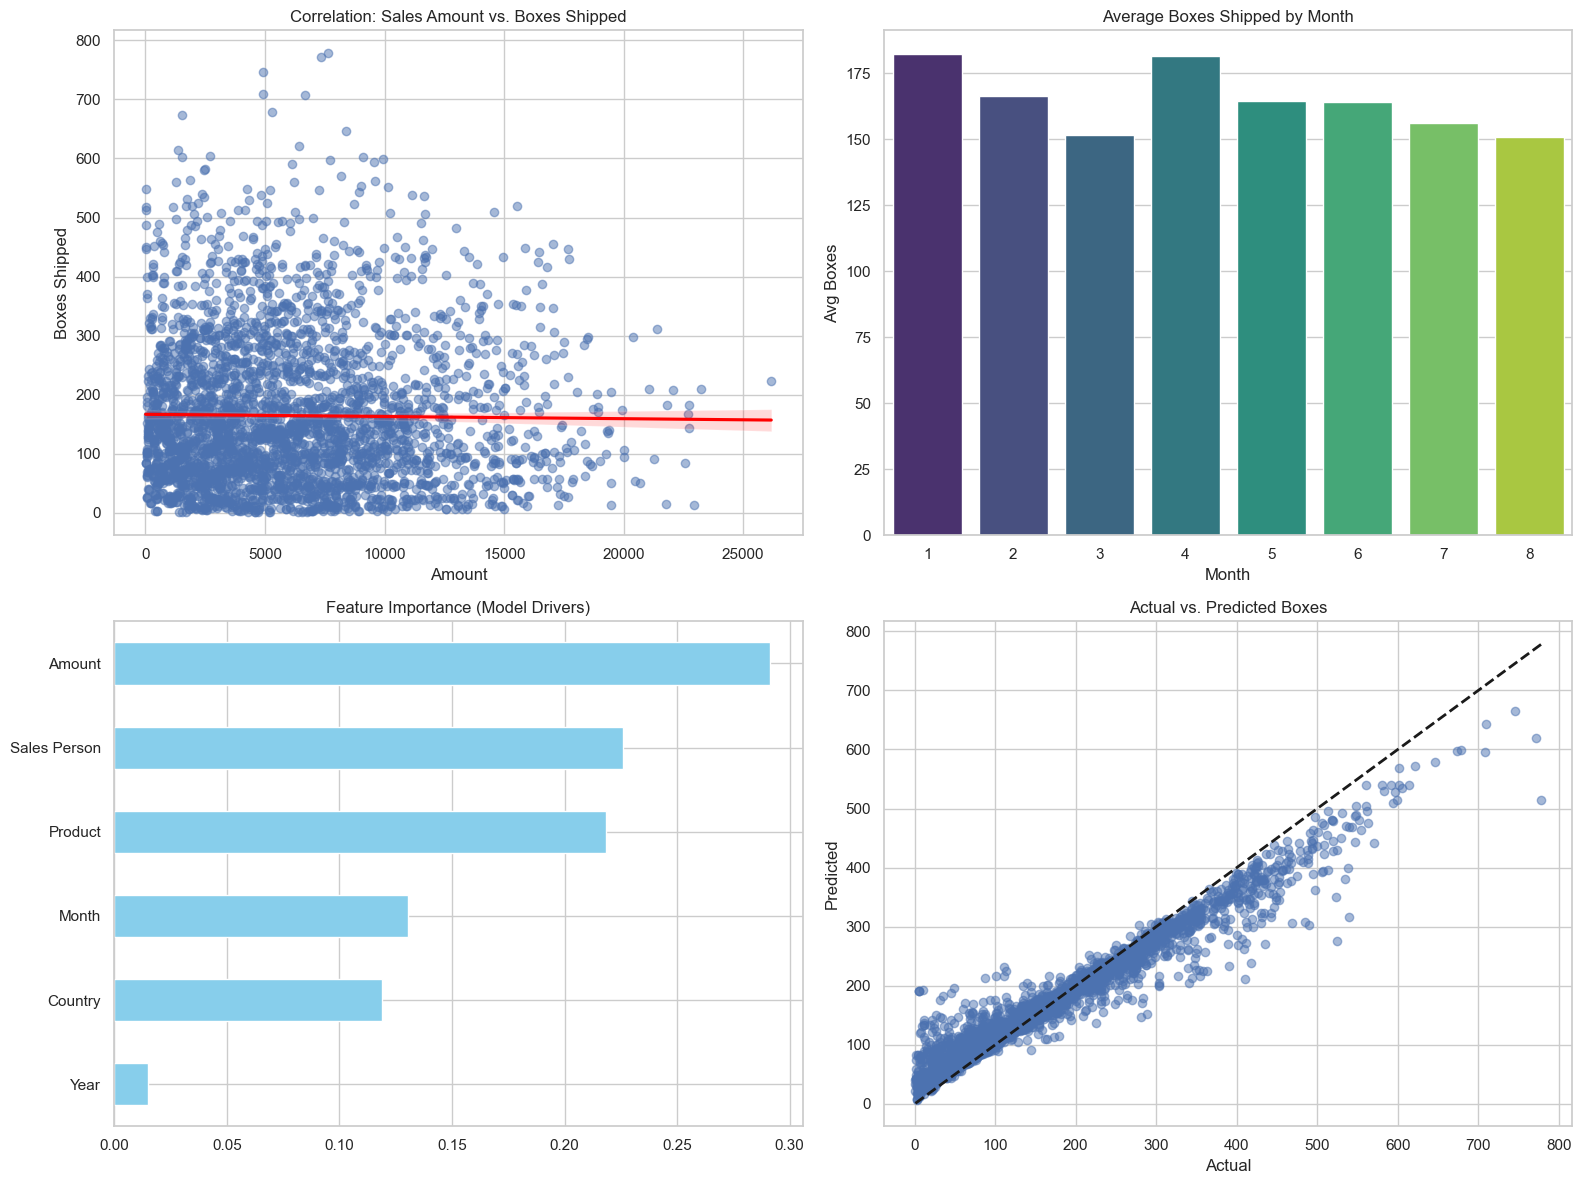

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 1. Relationship between Amount and Boxes Shipped
plt.subplot(2, 2, 1)
sns.regplot(data=df, x='Amount', y='Boxes Shipped', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Correlation: Sales Amount vs. Boxes Shipped')

# 2. Monthly Trends (Seasonality)
plt.subplot(2, 2, 2)
monthly_avg = df.groupby('Month')['Boxes Shipped'].mean()
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='viridis')
plt.title('Average Boxes Shipped by Month')
plt.ylabel('Avg Boxes')

# 3. Feature Importance (What the Random Forest cares about most)
plt.subplot(2, 2, 3)
importances = model.feature_importances_
feature_names = X.columns
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)
feat_importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importance (Model Drivers)')

# 4. Actual vs Predicted (How accurate is the model?)
plt.subplot(2, 2, 4)
y_pred = model.predict(scaler.transform(X))
plt.scatter(df['Boxes Shipped'], y_pred, alpha=0.5)
plt.plot([df['Boxes Shipped'].min(), df['Boxes Shipped'].max()], 
         [df['Boxes Shipped'].min(), df['Boxes Shipped'].max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted Boxes')

plt.tight_layout()
plt.show()

In [18]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# 1. Create a dropdown for Countries
country_selector = widgets.Dropdown(
    options=sorted(df['Country'].unique()),
    value=df['Country'].unique()[0],
    description='Select Country:',
    style={'description_width': 'initial'}
)

output_plot = widgets.Output()

def update_country_forecast(change):
    with output_plot:
        clear_output(wait=True)
        selected_country = change['new']
        
        # Prepare future timeline
        future_data = []
        for year in [2024, 2025, 2026]:
            for month in range(1, 13):
                # We use average 'Amount' and common IDs to see the baseline trend
                row = pd.DataFrame({
                    'Sales Person': [df['Sales Person'].mode()[0]],
                    'Country': [selected_country],
                    'Product': [df['Product'].mode()[0]],
                    'Amount': [df['Amount'].median()],
                    'Year': [year],
                    'Month': [month]
                })
                # Match column order and predict
                row = row[X.columns]
                pred = model.predict(scaler.transform(row))[0]
                future_data.append({'Date': f"{year}-{month}", 'Predicted': pred})
        
        forecast_df = pd.DataFrame(future_data)
        
        # Plotting the trend
        plt.figure(figsize=(12, 5))
        plt.plot(forecast_df['Date'], forecast_df['Predicted'], marker='o', color='#2ca02c', linestyle='-')
        plt.xticks(rotation=45)
        plt.title(f"Shipping Forecast for Country ID: {selected_country} (2024-2026)")
        plt.ylabel("Predicted Boxes")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# Link the dropdown to the function
country_selector.observe(update_country_forecast, names='value')

# Display everything
print("--- Country-Wise Future Insights ---")
display(country_selector, output_plot)

# Trigger initial plot
update_country_forecast({'new': country_selector.value})

--- Country-Wise Future Insights ---


Dropdown(description='Select Country:', index=4, options=(np.int64(0), np.int64(1), np.int64(2), np.int64(3), …

Output()

In [19]:
df


,Sales Person,Country,Product,Amount,Boxes Shipped,Year,Month
0,13,4,14,5320.00,180,2022,1
1,23,2,2,7896.00,94,2022,8
2,9,2,17,4501.00,91,2022,7
3,12,0,17,12726.00,342,2022,4
4,13,4,17,13685.00,184,2022,2
...,...,...,...,...,...,...,...
3277,15,0,20,5303.58,354,2024,5
3278,13,5,21,7339.32,121,2024,6
3279,5,1,16,616.09,238,2024,7
3280,8,2,10,2504.62,397,2024,7
